In [ ]:
# ========================================
# CONFIGURACIÓN INICIAL Y DIBUJO DEL LOTE
# ========================================
import matplotlib.pyplot as plt
import ee
import geemap
import geopandas as gpd
import requests
import pandas as pd
import tempfile
import ipywidgets as widgets
from traitlets import link
from shapely.geometry import shape
from IPython.display import display
from contextlib import redirect_stdout
from ipyleaflet import link


try:
    ee.Initialize(project='my-project-12126-484118')
    print("Earth Engine inicializado.")
except Exception as e:
    print("Autenticando Earth Engine...")
    ee.Authenticate()
    ee.Initialize(project='my-project-12126-484118')

print("\n--- PASO 1: DIBUJA TU LOTE ---")
print("Usa el polígono de la izquierda para dibujar. Cuando termines, vuelve a ejecutar esta celda.")
Draw_Map = geemap.Map(center=[33.584, -101.845], zoom=14)
Draw_Map.add_basemap('SATELLITE')
display(Draw_Map)



Earth Engine inicializado.

--- PASO 1: DIBUJA TU LOTE ---
Usa el polígono de la izquierda para dibujar. Cuando termines, vuelve a ejecutar esta celda.


Map(center=[33.584, -101.845], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

Configurando geometría del lote...
📡 Descargando datos desde 2023-04-13 hasta 2026-04-13...
⏳ Procesando cientos de imágenes satelitales (esto puede tardar 1-2 minutos)...
✅ Datos procesados. Generando gráfico...


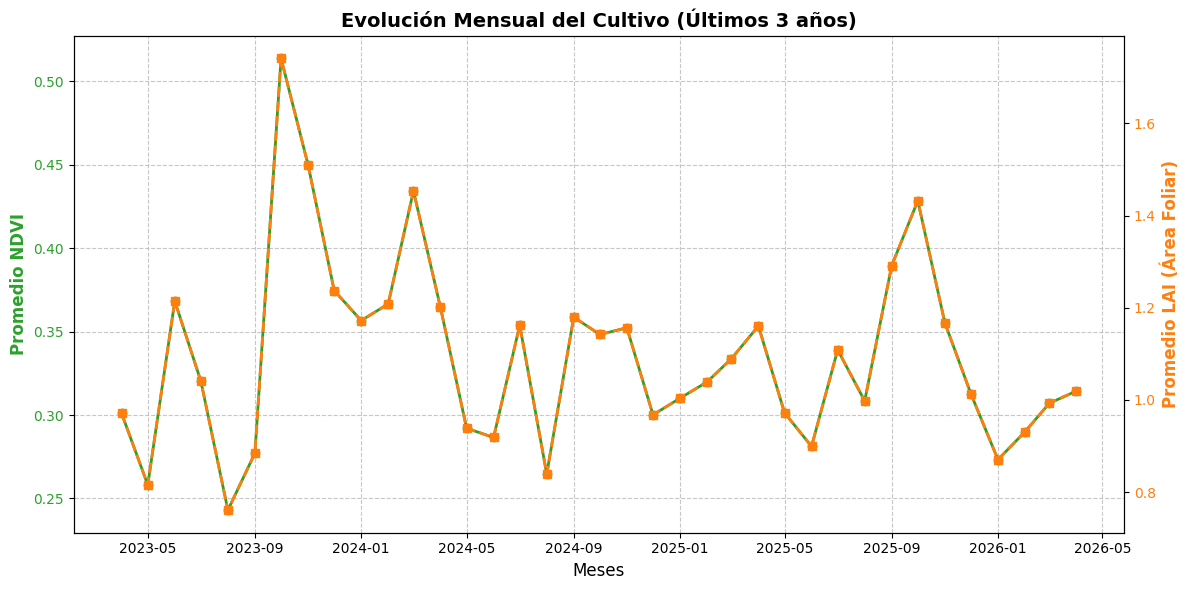

✅ NDVI y LAI calculados con éxito para tu AOI.


Map(center=[33.584, -101.845], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topri…

In [ ]:
# ========================================
# 2. DESCARGA, NDVI Y 4 PANELES (CORREGIDO)
# ========================================

# 1. VERIFICACIÓN Y CAPTURA
roi = Draw_Map.user_roi
if roi is None:
    raise ValueError("⚠️ ¡Error! No detecto el dibujo. Ve a la Celda 1, dibuja el lote y luego vuelve aquí.")

# 2. CAPTURA DE GEOMETRÍA SÓLIDA (Para evitar grietas)
print("Configurando geometría del lote...")
roi_info = roi.getInfo()
# Creamos una geometría ÚNICA y SÓLIDA del dibujo original
lote_geom = ee.Geometry(roi_info['geometry'] if 'geometry' in roi_info else roi_info)

# 1. Definir fechas dinámicas (Desde hace 3 años exactos hasta hoy)
fecha_fin = pd.Timestamp.today()
fecha_inicio = fecha_fin - pd.DateOffset(years=3)

fecha_fin_str = fecha_fin.strftime('%Y-%m-%d')
fecha_inicio_str = fecha_inicio.strftime('%Y-%m-%d')

print(f"📡 Descargando datos desde {fecha_inicio_str} hasta {fecha_fin_str}...")

# 2. Función para calcular índices
def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    lai = ndvi.multiply(3.618).subtract(0.118).rename('LAI')
    return image.addBands([ndvi, lai]).copyProperties(image, ['system:time_start'])

# 3. Filtrar colección Sentinel-2 (Máximo 30% nubes para tener buena data)
s2_col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
          .filterBounds(lote_geom)
          .filterDate(fecha_inicio_str, fecha_fin_str)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
          .map(add_indices))

# 4. Función para extraer el promedio del lote en CADA imagen
def extract_stats(image):
    # Calcula el promedio de NDVI y LAI dentro de tu lote
    mean_dict = image.select(['NDVI', 'LAI']).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=lote_geom,
        scale=10,
        maxPixels=1e9
    )
    # Extrae la fecha de la imagen
    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')
    
    return ee.Feature(None, {
        'date': date,
        'NDVI': mean_dict.get('NDVI'),
        'LAI': mean_dict.get('LAI')
    })

# 5. Ejecutar la extracción en los servidores de Google
print("⏳ Procesando cientos de imágenes satelitales (esto puede tardar 1-2 minutos)...")
ts_features = ee.FeatureCollection(s2_col.map(extract_stats))
ts_list = ts_features.getInfo()['features']

# 6. Convertir a Pandas y agrupar por MES
datos = []
for f in ts_list:
    props = f['properties']
    # Filtrar imágenes que por nubes no devolvieron datos
    if props.get('NDVI') is not None:
        datos.append({
            'Fecha': pd.to_datetime(props['date']),
            'NDVI': props['NDVI'],
            'LAI': props['LAI']
        })

df = pd.DataFrame(datos)
df.set_index('Fecha', inplace=True)

# ¡La magia de Pandas! Agrupa todas las imágenes del mes y saca el promedio
df_mensual = df.resample('MS').mean() 
df_mensual.dropna(inplace=True) # Elimina meses donde hubo 100% de nubes y no hay fotos

print("✅ Datos procesados. Generando gráfico...")

# 7. Graficar
fig, ax1 = plt.subplots(figsize=(12, 6))

# Línea de NDVI (Eje izquierdo)
color1 = 'tab:green'
ax1.set_xlabel('Meses', fontsize=12)
ax1.set_ylabel('Promedio NDVI', color=color1, fontsize=12, fontweight='bold')
ax1.plot(df_mensual.index, df_mensual['NDVI'], marker='o', color=color1, linewidth=2, label='NDVI')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.7)

# Línea de LAI (Eje derecho)
ax2 = ax1.twinx()  
color2 = 'tab:orange'
ax2.set_ylabel('Promedio LAI (Área Foliar)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(df_mensual.index, df_mensual['LAI'], marker='s', color=color2, linewidth=2, linestyle='--', label='LAI')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f'Evolución Mensual del Cultivo (Últimos 3 años)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


print("✅ NDVI y LAI calculados con éxito para tu AOI.")
Map = geemap.Map(center=[33.584, -101.845], zoom=15)
vis_ndvi = {'min': 0, 'max': 0.8, 'palette': ['red', 'yellow', 'green']}
vis_lai = {'min': 0, 'max': 4, 'palette': ['#ffffcc', '#c2e699', '#78c679', '#31a354', '#006837']}
Map.addLayer(s2_col.select('NDVI'), vis_ndvi, 'NDVI (Mediana)')
Map.addLayer(s2_col.select('LAI'), vis_lai, 'LAI (Área Foliar)')
Map.addLayer(ee.Image().paint(lote_geom, 0, 2), {'palette': 'red'}, 'Mi Lote')
display(Map)